<a href="https://colab.research.google.com/github/PraveenkkumarNS/Assignment-AIML/blob/main/homeprices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub
path = kagglehub.dataset_download("camnugent/california-housing-prices")

Using Colab cache for faster access to the 'california-housing-prices' dataset.


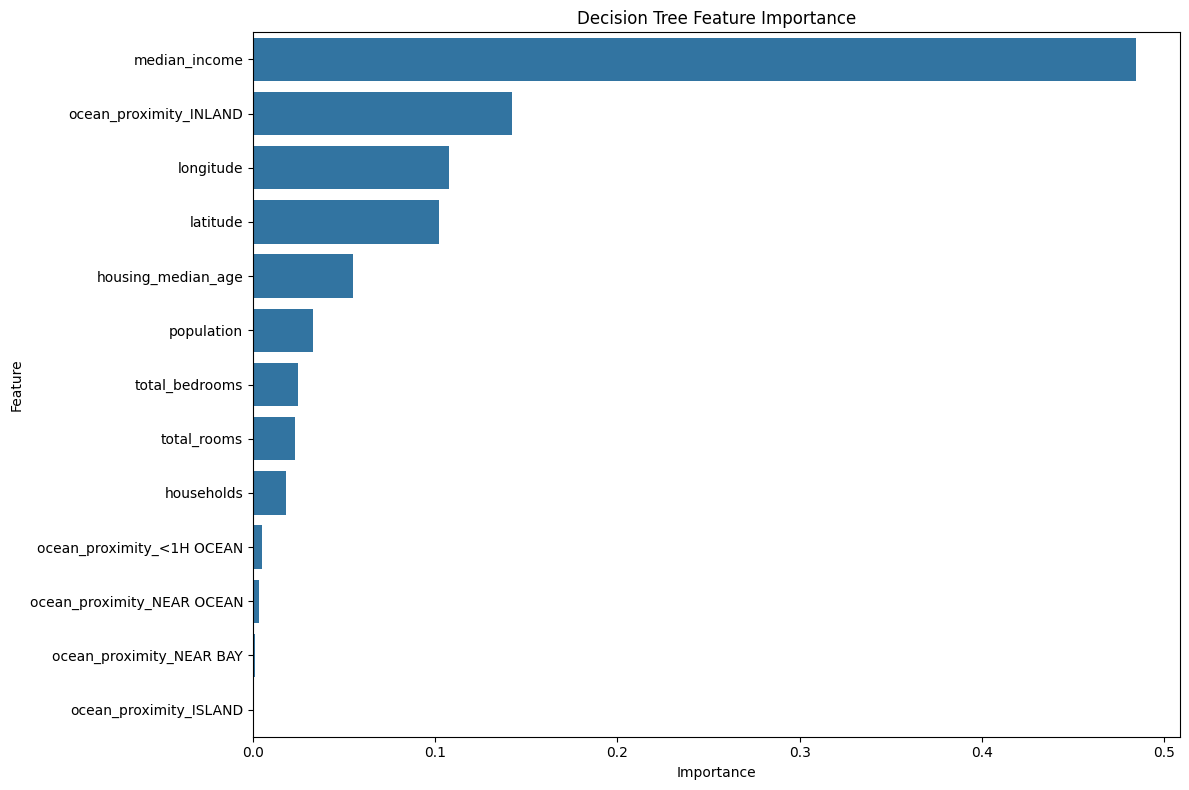

,Feature,Importance
7,median_income,0.484422
9,ocean_proximity_INLAND,0.142227
0,longitude,0.107833
1,latitude,0.101871
2,housing_median_age,0.055037
5,population,0.033166
4,total_bedrooms,0.024808
3,total_rooms,0.023309
6,households,0.018028
8,ocean_proximity_<1H OCEAN,0.005216


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the trained Decision Tree pipeline
dt_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                ('regressor', models['Decision Tree'])])
dt_pipeline.fit(X_train, y_train)

# Access the trained Decision Tree Regressor model
decision_tree_model = dt_pipeline.named_steps['regressor']

# Get feature importances
feature_importances_dt = decision_tree_model.feature_importances_

# Get feature names after preprocessing (these are the same as before)
# For numerical features
numeric_feature_names = preprocessor.named_transformers_['num'].get_feature_names_out(numeric_features)

# For categorical features (after one-hot encoding)
categorical_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)

# Combine all feature names
all_feature_names_dt = list(numeric_feature_names) + list(categorical_feature_names)

# Create a DataFrame for better visualization
importance_df_dt = pd.DataFrame({
    'Feature': all_feature_names_dt,
    'Importance': feature_importances_dt
})

# Sort by importance
importance_df_dt = importance_df_dt.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_dt)
plt.title('Decision Tree Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

display(importance_df_dt.head(10))

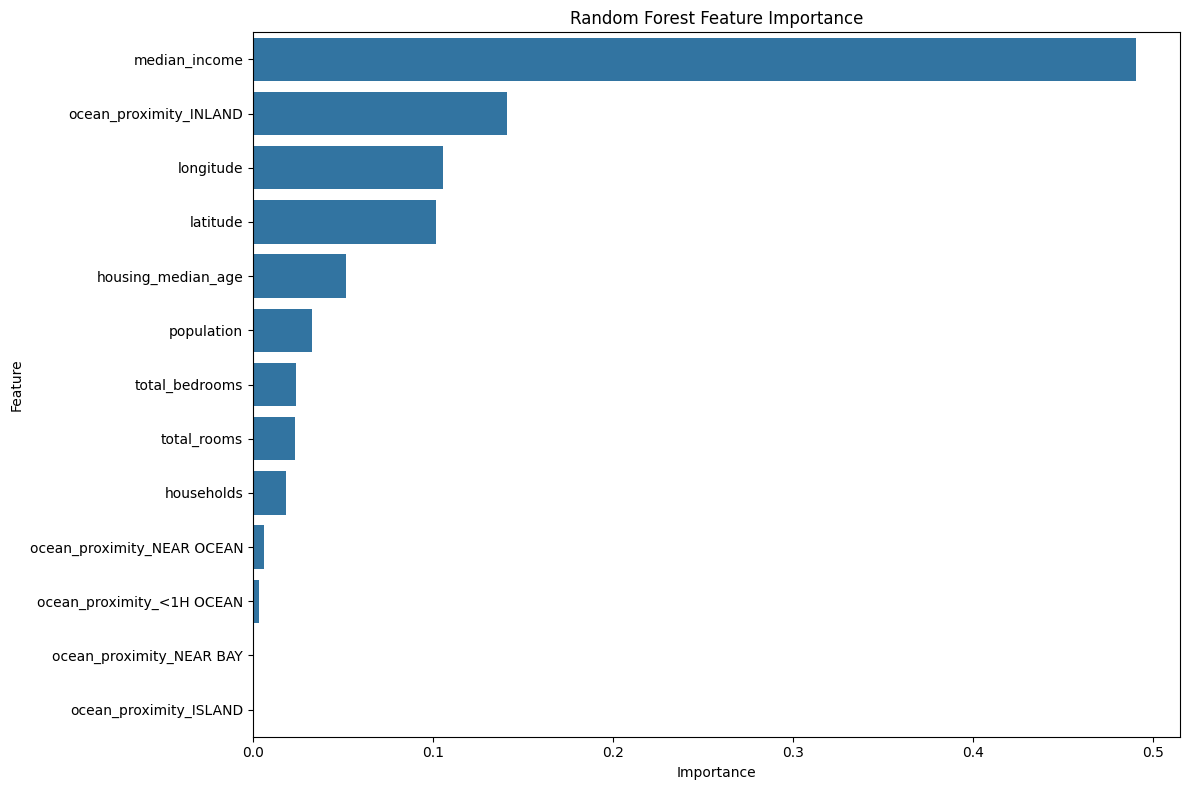

,Feature,Importance
7,median_income,0.490642
9,ocean_proximity_INLAND,0.140925
0,longitude,0.105889
1,latitude,0.101597
2,housing_median_age,0.051935
5,population,0.032573
4,total_bedrooms,0.023819
3,total_rooms,0.023366
6,households,0.018367
12,ocean_proximity_NEAR OCEAN,0.006336


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the trained Random Forest pipeline
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                ('regressor', models['Random Forest'])])
rf_pipeline.fit(X_train, y_train)

# Access the trained Random Forest Regressor model
random_forest_model = rf_pipeline.named_steps['regressor']

# Get feature importances
feature_importances = random_forest_model.feature_importances_

# Get feature names after preprocessing
# For numerical features
numeric_feature_names = preprocessor.named_transformers_['num'].get_feature_names_out(numeric_features)

# For categorical features (after one-hot encoding)
categorical_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)

# Combine all feature names
all_feature_names = list(numeric_feature_names) + list(categorical_feature_names)

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

display(importance_df.head(10))

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    # Create a full pipeline including preprocessing and the model
    full_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                    ('regressor', model)])

    # Train the model
    full_pipeline.fit(X_train, y_train)

    # Make predictions
    y_pred = full_pipeline.predict(X_test)

    # Evaluate the model
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse**0.5 # Root Mean Squared Error
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

    print(f"{name} Evaluation:")
    print(f"  Mean Absolute Error (MAE): {mae:.2f}")
    print(f"  Mean Squared Error (MSE): {mse:.2f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"  R-squared (R2): {r2:.2f}")

print("\n--- Model Training and Evaluation Complete ---")
for name, metrics in results.items():
    print(f"\n{name} Results:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.2f}")



Training Linear Regression...
Linear Regression Evaluation:
  Mean Absolute Error (MAE): 50702.17
  Mean Squared Error (MSE): 4904409297.41
  Root Mean Squared Error (RMSE): 70031.49
  R-squared (R2): 0.63

Training Decision Tree...
Decision Tree Evaluation:
  Mean Absolute Error (MAE): 43628.22
  Mean Squared Error (MSE): 4796121126.69
  Root Mean Squared Error (RMSE): 69254.03
  R-squared (R2): 0.63

Training Random Forest...
Random Forest Evaluation:
  Mean Absolute Error (MAE): 31660.47
  Mean Squared Error (MSE): 2393815007.89
  Root Mean Squared Error (RMSE): 48926.63
  R-squared (R2): 0.82

--- Model Training and Evaluation Complete ---

Linear Regression Results:
  MAE: 50702.17
  MSE: 4904409297.41
  RMSE: 70031.49
  R2: 0.63

Decision Tree Results:
  MAE: 43628.22
  MSE: 4796121126.69
  RMSE: 69254.03
  R2: 0.63

Random Forest Results:
  MAE: 31660.47
  MSE: 2393815007.89
  RMSE: 48926.63
  R2: 0.82


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    # Create a full pipeline including preprocessing and the model
    full_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                    ('regressor', model)])

    # Train the model
    full_pipeline.fit(X_train, y_train)

    # Make predictions
    y_pred = full_pipeline.predict(X_test)

    # Evaluate the model
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse**0.5 # Root Mean Squared Error
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

    print(f"{name} Evaluation:")
    print(f"  Mean Absolute Error (MAE): {mae:.2f}")
    print(f"  Mean Squared Error (MSE): {mse:.2f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"  R-squared (R2): {r2:.2f}")

print("\n--- Model Training and Evaluation Complete ---")
for name, metrics in results.items():
    print(f"\n{name} Results:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.2f}")



Training Linear Regression...
Linear Regression Evaluation:
  Mean Absolute Error (MAE): 50702.17
  Mean Squared Error (MSE): 4904409297.41
  Root Mean Squared Error (RMSE): 70031.49
  R-squared (R2): 0.63

Training Decision Tree...
Decision Tree Evaluation:
  Mean Absolute Error (MAE): 43628.22
  Mean Squared Error (MSE): 4796121126.69
  Root Mean Squared Error (RMSE): 69254.03
  R-squared (R2): 0.63

Training Random Forest...
Random Forest Evaluation:
  Mean Absolute Error (MAE): 31660.47
  Mean Squared Error (MSE): 2393815007.89
  Root Mean Squared Error (RMSE): 48926.63
  R-squared (R2): 0.82

--- Model Training and Evaluation Complete ---

Linear Regression Results:
  MAE: 50702.17
  MSE: 4904409297.41
  RMSE: 70031.49
  R2: 0.63

Decision Tree Results:
  MAE: 43628.22
  MSE: 4796121126.69
  RMSE: 69254.03
  R2: 0.63

Random Forest Results:
  MAE: 31660.47
  MSE: 2393815007.89
  RMSE: 48926.63
  R2: 0.82


In [3]:
import pandas as pd
import os

# Assuming the dataset contains 'housing.csv'
file_path = os.path.join(path, 'housing.csv')
df = pd.read_csv(file_path)

print("Dataset loaded successfully. Displaying the first 5 rows:")
display(df.head())

Dataset loaded successfully. Displaying the first 5 rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Before training, we need to preprocess the data. This involves handling missing values, encoding categorical features, and splitting the data into training and testing sets.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separate target variable (median_house_value) from features
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# Identify numerical and categorical features
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Create preprocessing pipelines for numerical and categorical features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data preprocessing pipeline created and data split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Data preprocessing pipeline created and data split into training and testing sets.
X_train shape: (16512, 9)
X_test shape: (4128, 9)
